In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt


### Exploratory Data Analysis

In [ ]:
bureau_data = pd.read_csv('data/bureau_data.csv')
customers_data = pd.read_csv('data/customers.csv')
loans_data = pd.read_csv('data/loans.csv')

In [4]:
bureau_data.head()

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58
3,C00004,3,0,115,15,87,5,26
4,C00005,4,2,120,0,0,5,10


In [5]:
customers_data.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001


In [6]:
loans_data.head()

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [7]:
df = pd.merge(customers_data, bureau_data, on='cust_id')
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001,4,2,120,0,0,5,10


In [8]:
df = pd.merge(df, loans_data, on='cust_id')
print(f"The Shape of Data is {df.shape}.")
df.head()

The Shape of Data is (50000, 33).


,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  str    
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  str    
 3   marital_status               50000 non-null  str    
 4   employment_status            50000 non-null  str    
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  str    
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  str    
 10  state                        50000 non-null  str    
 11  zipcode                      50000 non-null  int64  
 12  number_of_open_accounts      50000 non-null  int64  
 13  number_of_closed_accounts  

In [10]:
df['default'] = df['default'].astype('int64')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  str    
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  str    
 3   marital_status               50000 non-null  str    
 4   employment_status            50000 non-null  str    
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  str    
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  str    
 10  state                        50000 non-null  str    
 11  zipcode                      50000 non-null  int64  
 12  number_of_open_accounts      50000 non-null  int64  
 13  number_of_closed_accounts  

In [12]:
df.describe()

,age,income,number_of_dependants,years_at_current_address,zipcode,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,...,credit_utilization_ratio,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,default
count,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,...,50000.00000,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,50000.000000,5.000000e+04,5.000000e+04,50000.000000
mean,39.550980,2.640898e+06,1.939540,16.018440,419090.860000,2.500140,1.00106,76.127140,4.87890,26.858000,...,43.36142,4.704828e+06,3.999679e+06,8.049471e+04,7.199422e+05,3.199743e+06,25.940520,1.337636e+06,9.891264e+05,0.085940
std,9.847752,2.629441e+06,1.535517,8.926489,168982.674047,1.118725,0.81412,43.762469,5.85032,32.832832,...,29.35598,6.267276e+06,5.376552e+06,1.173123e+05,9.677794e+05,4.301242e+06,12.433163,1.214714e+06,1.046072e+06,0.280278
min,18.000000,0.000000e+00,0.000000,1.000000,110001.000000,1.000000,0.00000,1.000000,0.00000,0.000000,...,0.00000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000,-1.000000e+00,0.000000e+00,0.000000
25%,33.000000,8.030000e+05,0.000000,8.000000,302001.000000,1.000000,0.00000,42.000000,0.00000,0.000000,...,18.00000,1.147000e+06,9.670000e+05,1.934000e+04,1.740600e+05,7.736000e+05,16.000000,4.247990e+05,2.870075e+05,0.000000
50%,40.000000,1.892000e+06,2.000000,16.000000,400001.000000,3.000000,1.00000,71.000000,3.00000,14.000000,...,39.00000,2.656000e+06,2.240000e+06,4.480000e+04,4.032000e+05,1.792000e+06,24.000000,1.002309e+06,6.685250e+05,0.000000
75%,46.000000,3.332250e+06,3.000000,24.000000,560001.000000,4.000000,2.00000,107.000000,9.00000,46.000000,...,67.00000,5.172250e+06,4.611000e+06,9.224000e+04,8.299800e+05,3.688800e+06,35.000000,1.790751e+06,1.238667e+06,0.000000
max,70.000000,1.199900e+07,5.000000,31.000000,700001.000000,4.000000,2.00000,223.000000,24.00000,171.000000,...,99.00000,5.217500e+07,4.781900e+07,5.698030e+06,8.607420e+06,3.825520e+07,59.000000,5.000000e+06,7.846643e+06,1.000000


#### To avoid data leakage and inference of Test Data on Training data while Model Training, we perform train_test_split at very initial stage.

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

In [14]:
df_train = pd.concat([X_train, y_train], axis=1)
df_train.shape

(37500, 33)

In [15]:
df_test = pd.concat([X_test, y_test], axis=1)
df_test.shape

(12500, 33)

#### Check for Data Sanity and Duplicacy

In [16]:
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd                       0
enquiry_count                   0
credit_utilization_ratio        0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_a

In [17]:
df_train['residence_type'].value_counts()

residence_type
Owned       21133
Mortgage     8858
Rented       7462
Name: count, dtype: int64

In [18]:
# Mode of Residence Type
residence_type_mode = df_train['residence_type'].mode()[0]

In [19]:
# Replacing Null Values in 'residence_type' column with its Mode Value.
df_train.fillna({
    'residence_type': residence_type_mode
}, inplace=True)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,...,23442000,468840.0,4219560,18753600,28,5000000,4820526,2020-10-31,2020-11-11,0
32495,C32496,44,F,Single,Salaried,715000,0,Owned,27,Mumbai,...,1149000,22980.0,206820,919200,50,467229,216697,2022-10-22,2022-10-27,0
43675,C43676,38,M,Single,Salaried,3195000,0,Mortgage,26,Chennai,...,11296000,225920.0,2033280,9036800,32,1656773,1383842,2023-12-04,2023-12-29,0
9040,C09041,42,M,Married,Salaried,1500000,2,Mortgage,30,Bangalore,...,1695000,33900.0,305100,1356000,40,1023442,626203,2020-06-18,2020-07-07,0
13077,C13078,58,M,Married,Self-Employed,1817000,4,Owned,29,Pune,...,905000,18100.0,162900,724000,15,651599,585099,2020-11-12,2020-12-07,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28515,C28516,70,M,Single,Self-Employed,2470000,0,Owned,20,Kolkata,...,1420000,28400.0,255600,1136000,12,1022399,501594,2022-05-30,2022-06-09,0
5558,C05559,39,F,Single,Salaried,2472000,0,Rented,26,Kolkata,...,2753000,55060.0,495540,2202400,32,1123466,587429,2020-02-12,2020-02-17,0
45236,C45237,39,M,Married,Self-Employed,1329000,4,Owned,10,Pune,...,4479000,89580.0,806220,3583200,38,913243,517025,2024-01-30,2024-02-04,1
49228,C49229,33,M,Single,Salaried,1274000,2,Owned,26,Chennai,...,1890000,37800.0,340200,1512000,37,635515,475147,2024-06-24,2024-07-21,0


In [20]:
df_train.isna().sum()

cust_id                        0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_count                  0
credit_utilization_ratio       0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_

In [21]:
df_test.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 15
years_at_current_address        0
city                            0
state                           0
zipcode                         0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd                       0
enquiry_count                   0
credit_utilization_ratio        0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_a

In [22]:
df_test.fillna({
    'residence_type': residence_type_mode
}, inplace=True)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
19205,C19206,36,M,Married,Self-Employed,3728000,3,Owned,24,Jaipur,...,9890000,197800.0,1780200,7912000,46,1745379,806208,2021-06-24,2021-07-23,0
15514,C15515,43,F,Single,Self-Employed,2493000,0,Owned,23,Delhi,...,3087000,61740.0,555660,2469600,18,1675530,1019647,2021-02-09,2021-02-18,0
30367,C30368,30,M,Married,Self-Employed,3114000,4,Owned,27,Delhi,...,3323000,66460.0,598140,2658400,35,1613282,1000932,2022-08-06,2022-08-21,0
35347,C35348,37,F,Single,Salaried,570000,2,Owned,5,Pune,...,1559000,31180.0,280620,1247200,46,398614,167679,2023-02-03,2023-02-04,0
41814,C41815,48,F,Single,Salaried,662000,0,Mortgage,23,Chennai,...,1351000,27020.0,243180,1080800,44,383925,262180,2023-09-27,2023-10-17,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29297,C29298,27,M,Single,Self-Employed,185000,0,Owned,3,Jaipur,...,253000,5060.0,45540,202400,29,96645,65285,2022-06-28,2022-06-30,0
20567,C20568,40,M,Single,Self-Employed,430000,0,Rented,19,Kolkata,...,1363000,27260.0,245340,1090400,35,273282,158171,2021-08-13,2021-08-23,0
681,C00682,28,M,Married,Self-Employed,11961000,5,Rented,15,Bangalore,...,3660000,73200.0,658800,2928000,15,2635199,4652930,2019-08-18,2019-09-16,0
33682,C33683,31,M,Single,Salaried,3430000,1,Owned,29,Delhi,...,12534000,250680.0,2256120,10027200,37,1907851,1029321,2022-12-05,2022-12-17,0


In [23]:
df_test.isna().sum()

cust_id                        0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_count                  0
credit_utilization_ratio       0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_

In [24]:
df_train.duplicated().sum()

np.int64(0)

In [25]:
df_test.duplicated().sum()

np.int64(0)

#### Data Viz

In [26]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'loan_id', 'loan_purpose', 'loan_type',
       'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'disbursal_date', 'installment_start_dt',
       'default'],
      dtype='str')

In [27]:
df_train.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = ['age', 'income', 'number_of_dependants', 'years_at_current_address', 
       'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application']
numerical_cols

['age',
 'income',
 'number_of_dependants',
 'years_at_current_address',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'delinquent_months',
 'total_dpd',
 'enquiry_count',
 'credit_utilization_ratio',
 'sanction_amount',
 'loan_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application']

In [28]:
df_train['zipcode'] = df_train['zipcode'].astype(str)

In [29]:
df_test['zipcode'] = df_test['zipcode'].astype(str)

In [30]:
df_train.select_dtypes(include=['str']).columns
categorical_cols = ['gender', 'marital_status', 'employment_status',
       'residence_type', 'city', 'state', 'zipcode', 'loan_purpose',
       'loan_type']
categorical_cols

['gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'zipcode',
 'loan_purpose',
 'loan_type']

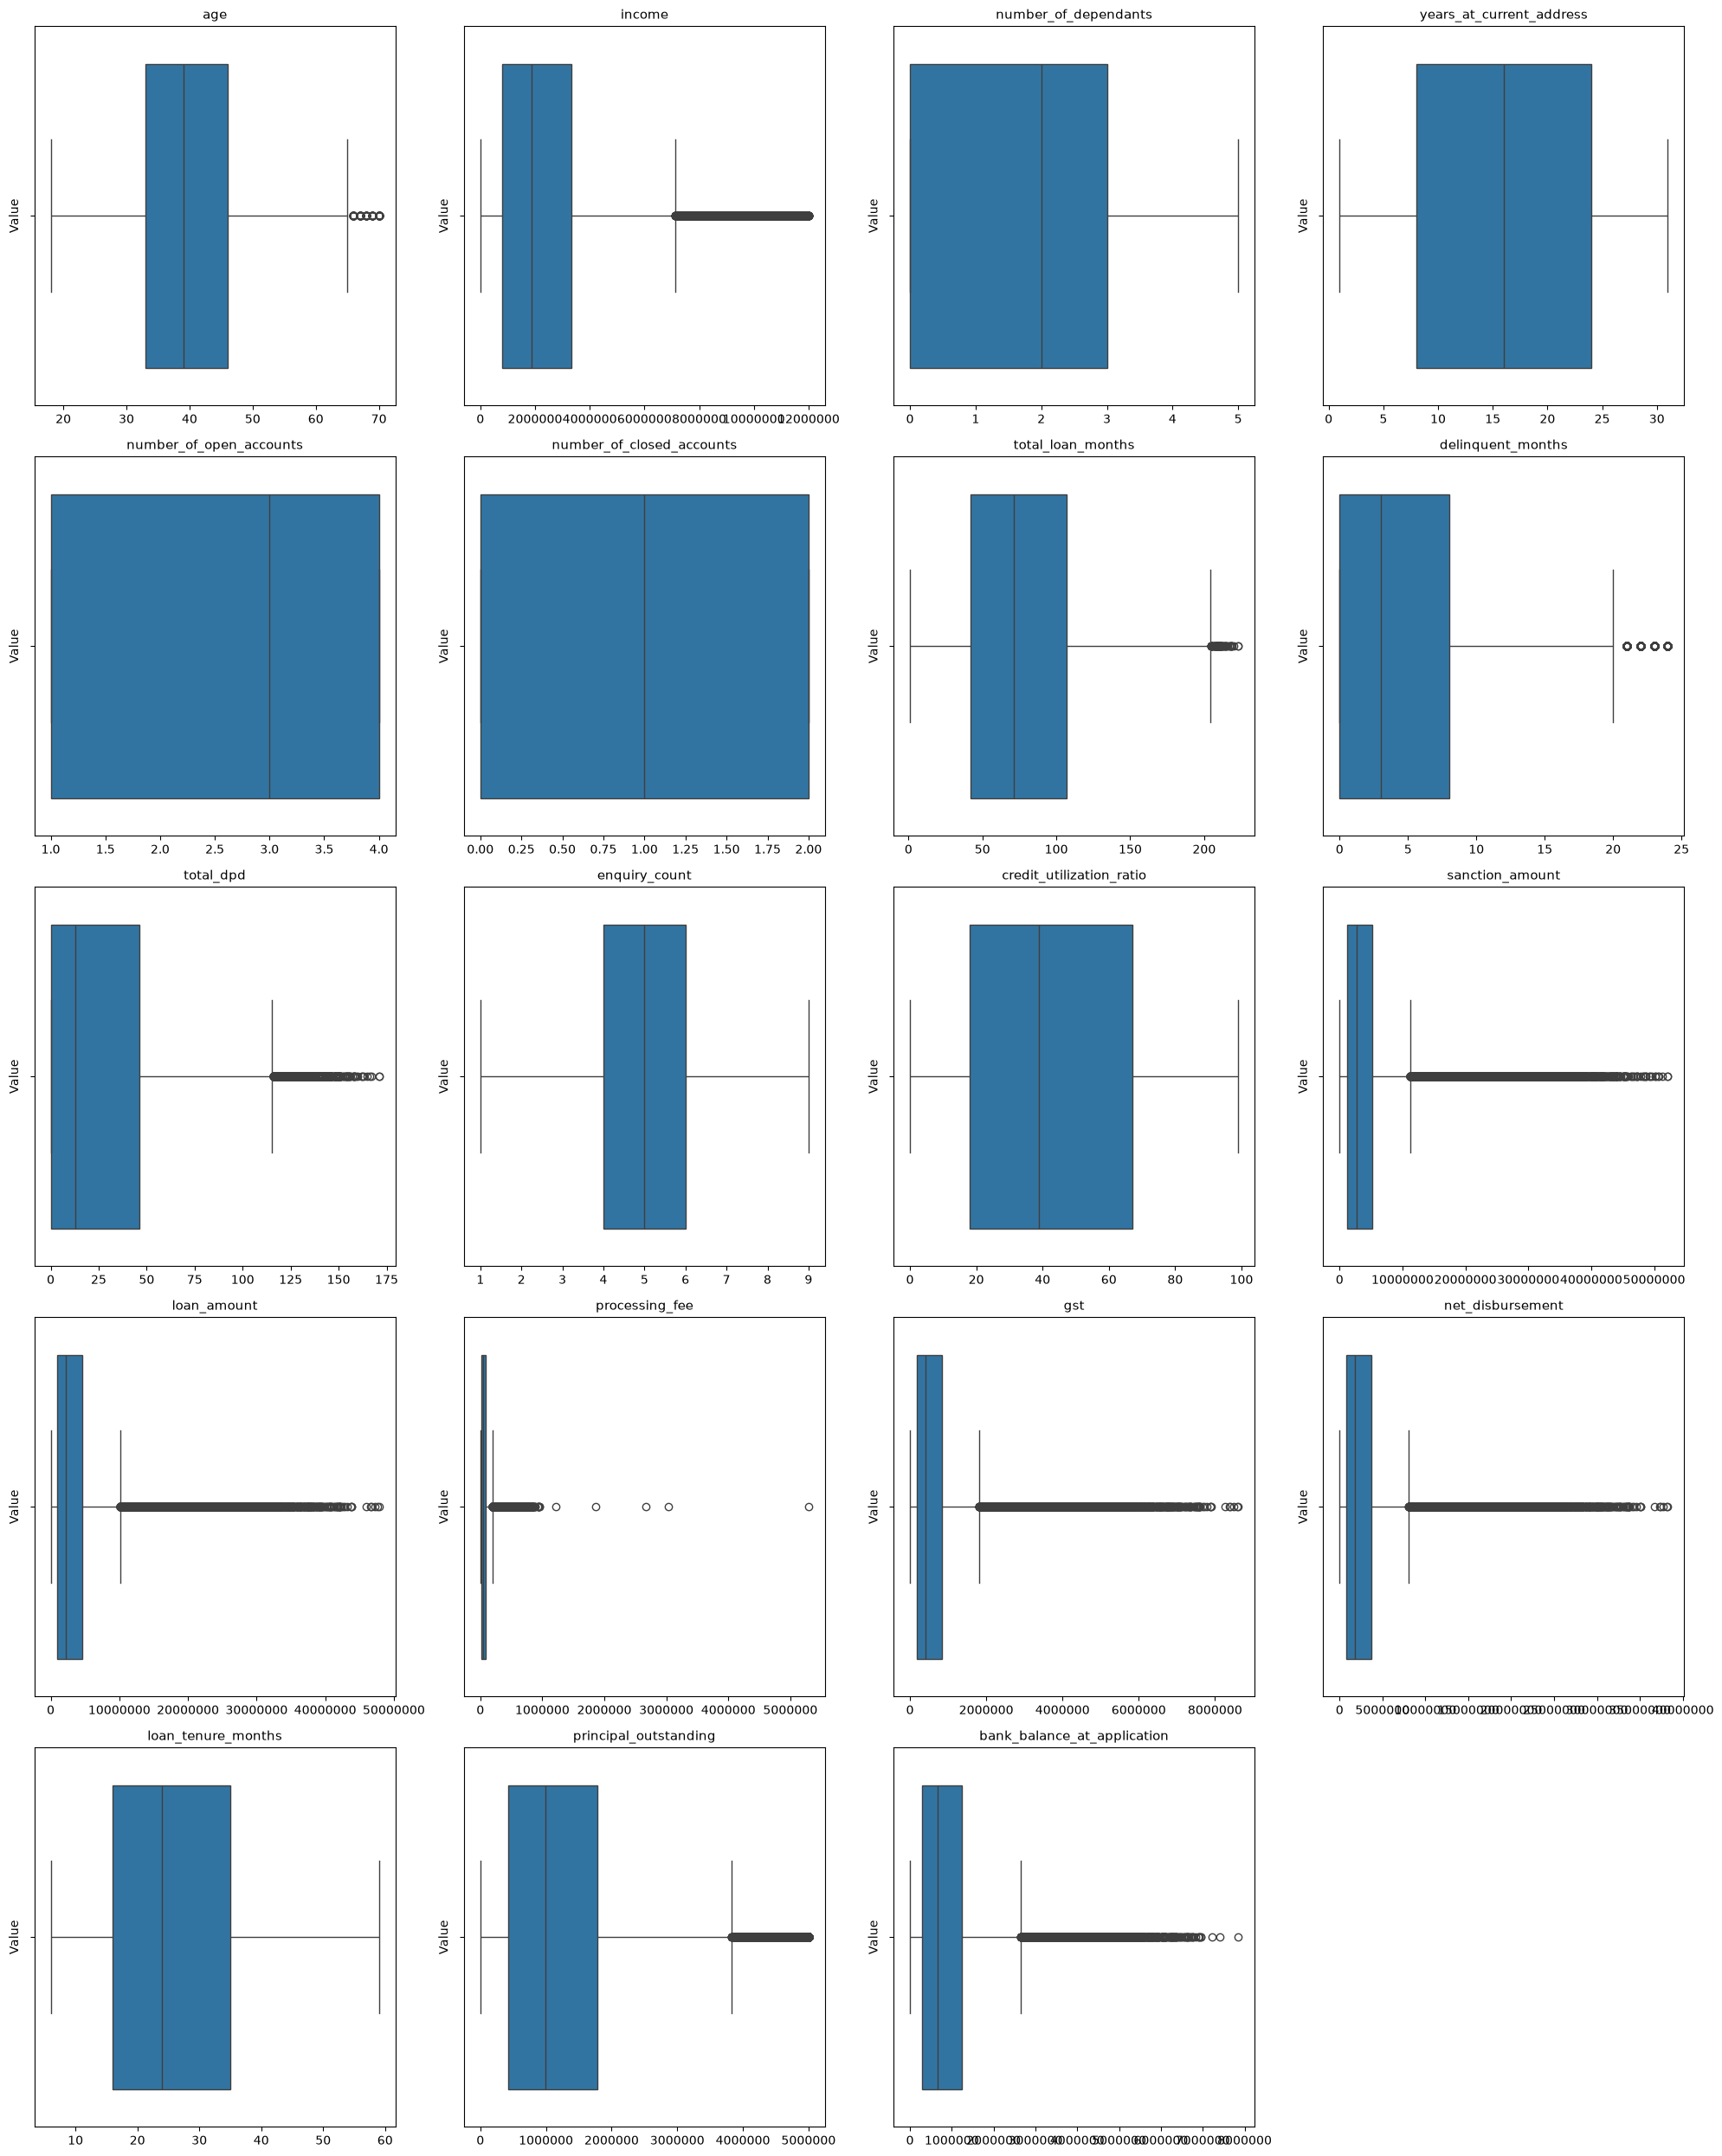

In [31]:
import math
# 4 plots in each row
n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, n_rows * 5)
)

# Flatten axes
axes = axes.flatten()

# Plot boxplots
for i, col in enumerate(numerical_cols):
    sns.boxplot(
        x=df_train[col],
        ax=axes[i]
    )
    
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Value')

    # Remove scientific notation
    axes[i].ticklabel_format(
        style='plain',
        axis='x',
        useOffset=False
    )

# Hide unused plots
for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

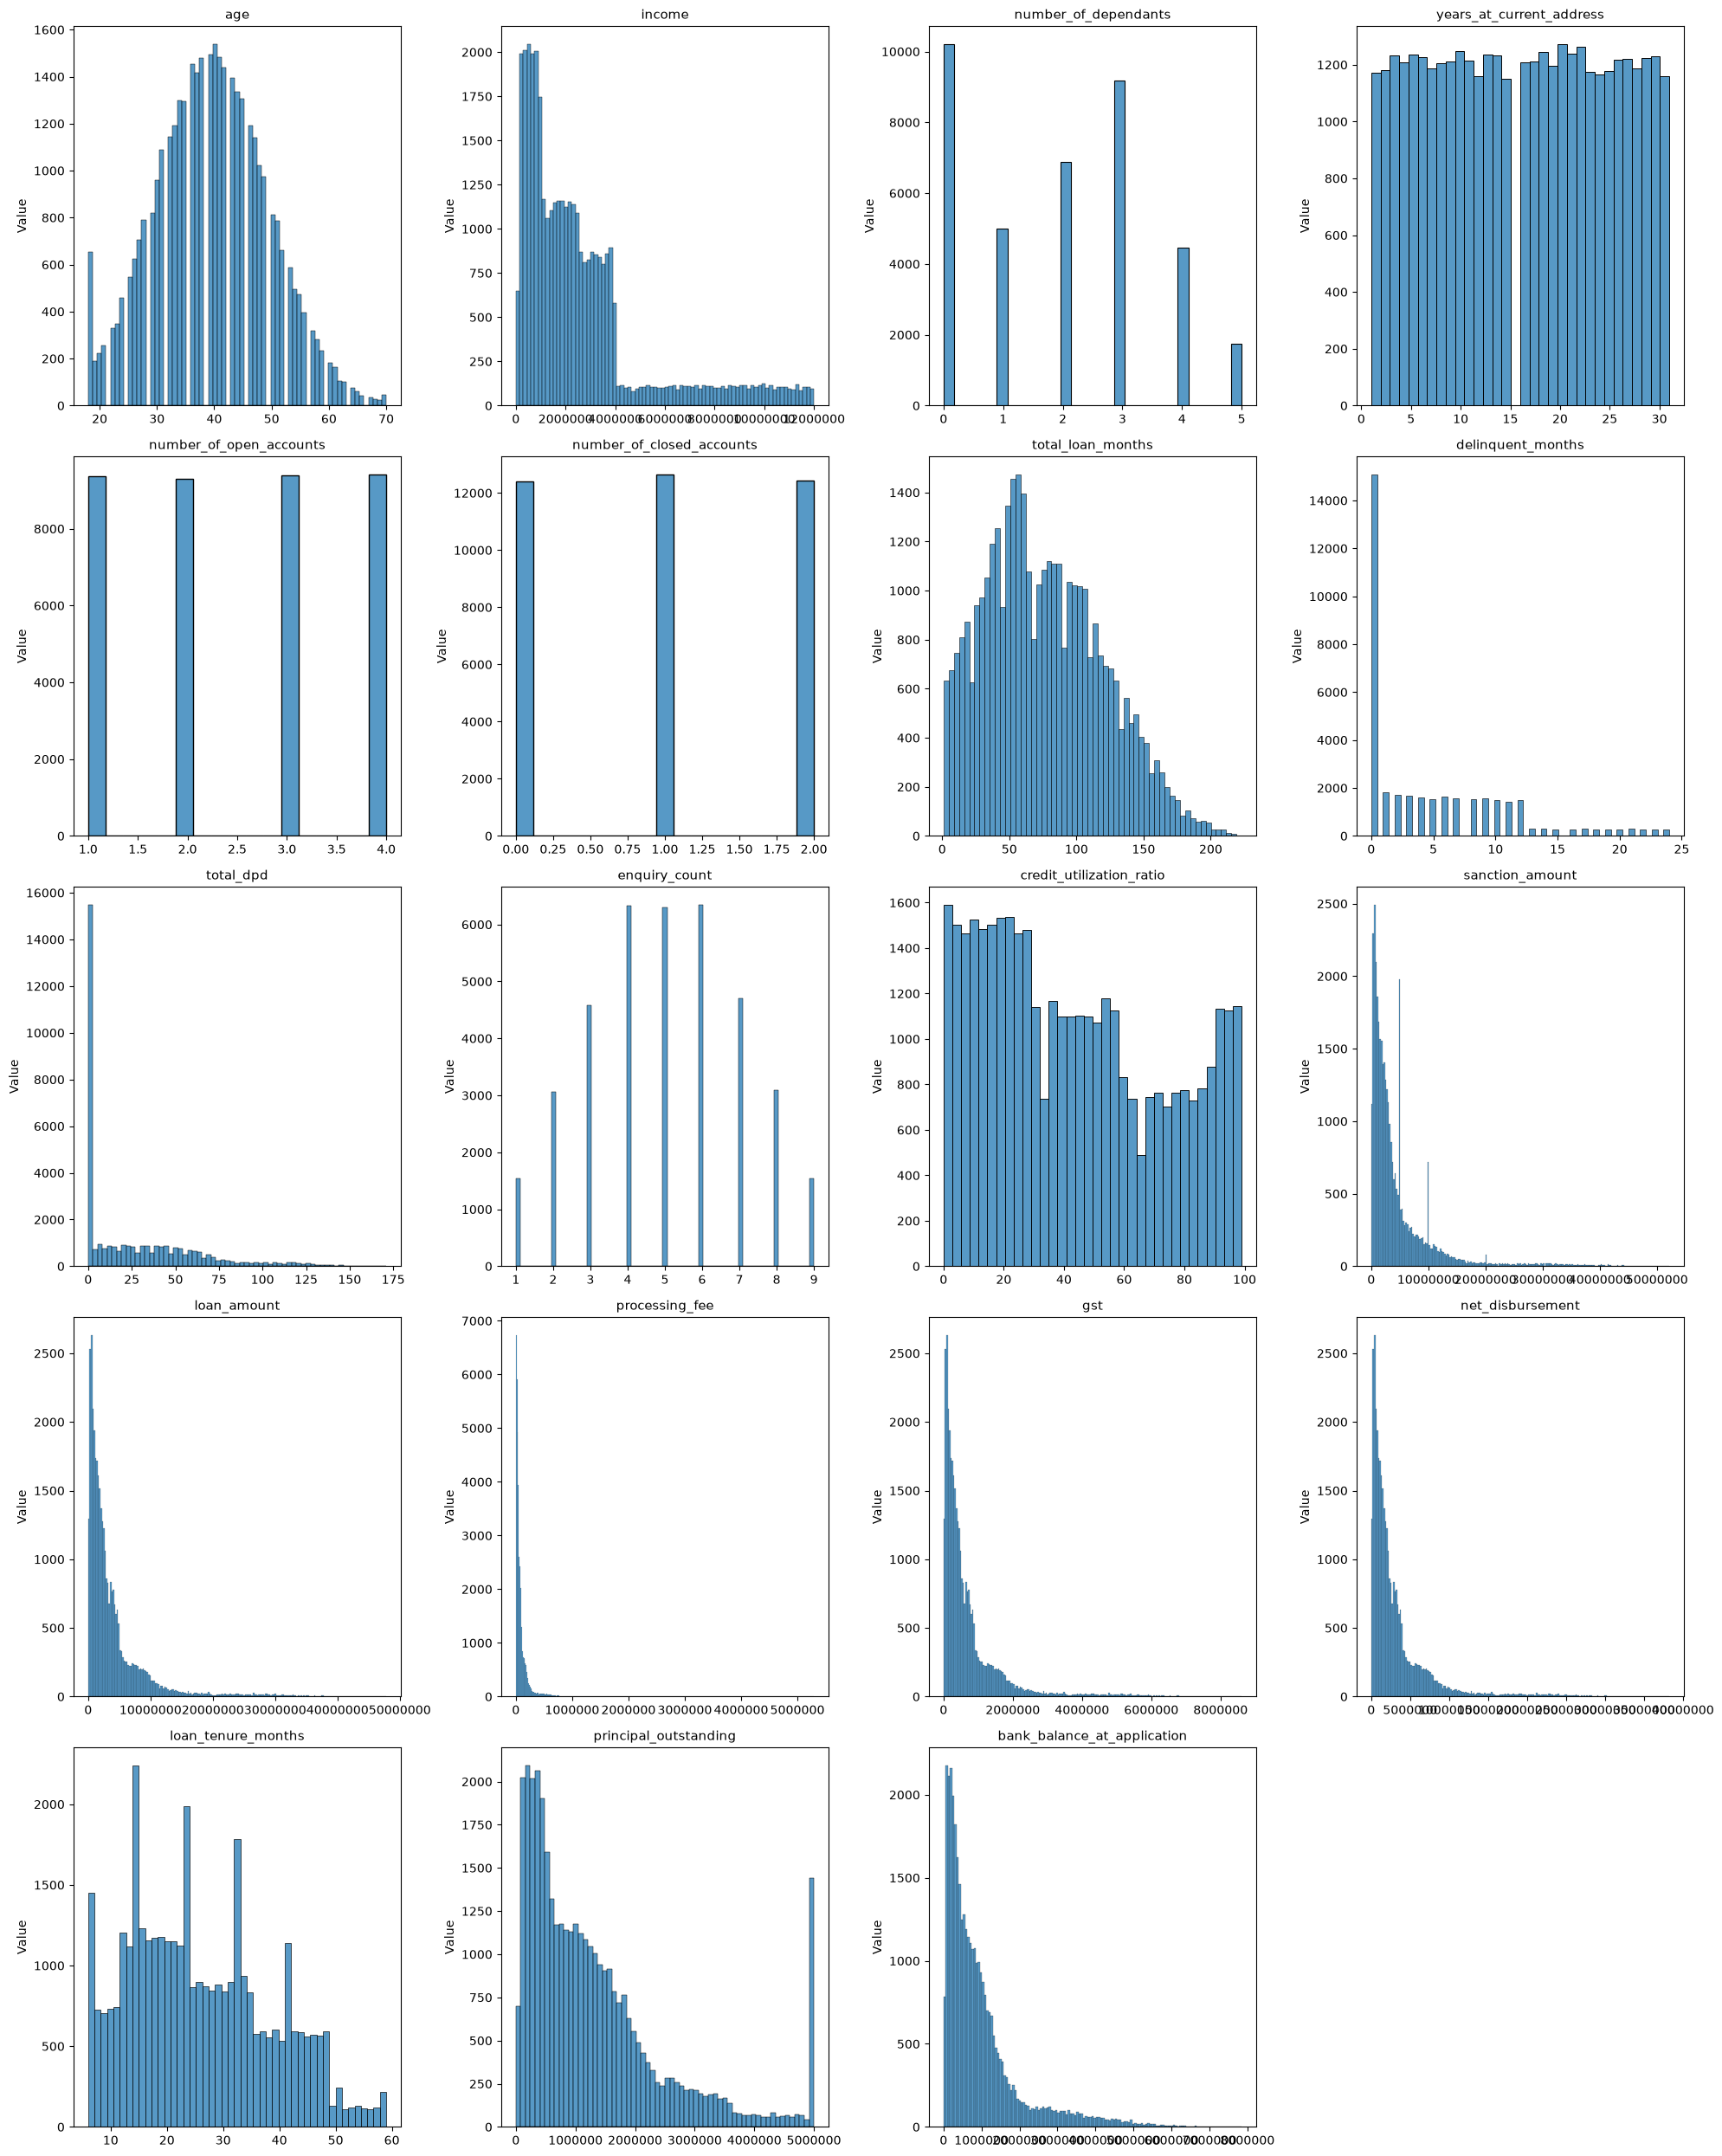

In [32]:
import math
# 4 plots in each row
n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, n_rows * 5)
)

# Flatten axes
axes = axes.flatten()

# Plot boxplots
for i, col in enumerate(numerical_cols):
    sns.histplot(
        x=df_train[col],
        ax=axes[i]
    )
    
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Value')

    # Remove scientific notation
    axes[i].ticklabel_format(
        style='plain',
        axis='x',
        useOffset=False
    )

# Hide unused plots
for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [33]:
df_train.describe()

,age,income,number_of_dependants,years_at_current_address,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,default
count,37500.000000,3.750000e+04,37500.000000,37500.000000,37500.000000,37500.000000,37500.00000,37500.000000,37500.000000,37500.000000,37500.000000,3.750000e+04,3.750000e+04,3.750000e+04,3.750000e+04,3.750000e+04,37500.000000,3.750000e+04,3.750000e+04,37500.000000
mean,39.540587,2.633326e+06,1.944533,15.997787,2.502907,1.001120,76.11104,4.844853,26.672613,5.008533,43.424880,4.699692e+06,3.996068e+06,8.029068e+04,7.192922e+05,3.196854e+06,25.961040,1.333820e+06,9.862989e+05,0.085947
std,9.858344,2.623781e+06,1.535943,8.921041,1.119070,0.814021,43.76852,5.841396,32.779424,2.029236,29.392857,6.257833e+06,5.371862e+06,1.131281e+05,9.669352e+05,4.297490e+06,12.447444,1.213674e+06,1.043145e+06,0.280289
min,18.000000,0.000000e+00,0.000000,1.000000,1.000000,0.000000,1.00000,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000,-1.000000e+00,0.000000e+00,0.000000
25%,33.000000,8.020000e+05,0.000000,8.000000,1.000000,0.000000,42.00000,0.000000,0.000000,4.000000,18.000000,1.142000e+06,9.610000e+05,1.922000e+04,1.729800e+05,7.688000e+05,16.000000,4.221975e+05,2.870402e+05,0.000000
50%,39.000000,1.885000e+06,2.000000,16.000000,3.000000,1.000000,71.00000,3.000000,13.000000,5.000000,39.000000,2.644000e+06,2.230000e+06,4.460000e+04,4.014000e+05,1.784000e+06,24.000000,9.974275e+05,6.650145e+05,0.000000
75%,46.000000,3.326250e+06,3.000000,24.000000,4.000000,2.000000,107.00000,8.000000,46.000000,6.000000,67.000000,5.178000e+06,4.619000e+06,9.242000e+04,8.314200e+05,3.695200e+06,35.000000,1.784879e+06,1.234063e+06,0.000000
max,70.000000,1.199900e+07,5.000000,31.000000,4.000000,2.000000,223.00000,24.000000,171.000000,9.000000,99.000000,5.217500e+07,4.781900e+07,5.293544e+06,8.607420e+06,3.825520e+07,59.000000,5.000000e+06,7.846643e+06,1.000000


In [34]:
df_train[df_train['sanction_amount'] < df_train['loan_amount']]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default


In [35]:
df_train[df_train['processing_fee'] > df_train.loan_amount][['processing_fee', 'loan_amount']]

,processing_fee,loan_amount
23981,2.669791e+06,2234000
28174,1.214493e+06,966000
47089,1.858965e+06,1738000
29305,3.036378e+06,2616000
9898,5.293544e+06,3626000


In [36]:
# processing fee is 3% of loan Amount

df_train = df_train[df_train['processing_fee'] <= (df_train['loan_amount'] * 0.03)]

In [37]:
df_test = df_test[df_test['processing_fee'] <= (df_test['loan_amount'] * 0.03)]

In [38]:
# GST is 18% of Loan Amount

df_train[df_train['gst'] > (df_train['loan_amount'] * 0.18)]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default


In [39]:
df_test[df_test['gst'] > (df_test['loan_amount'] * 0.18)]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default


#### Bi-Variate Analysis
- Analyzing every numerical features with target class outputs.

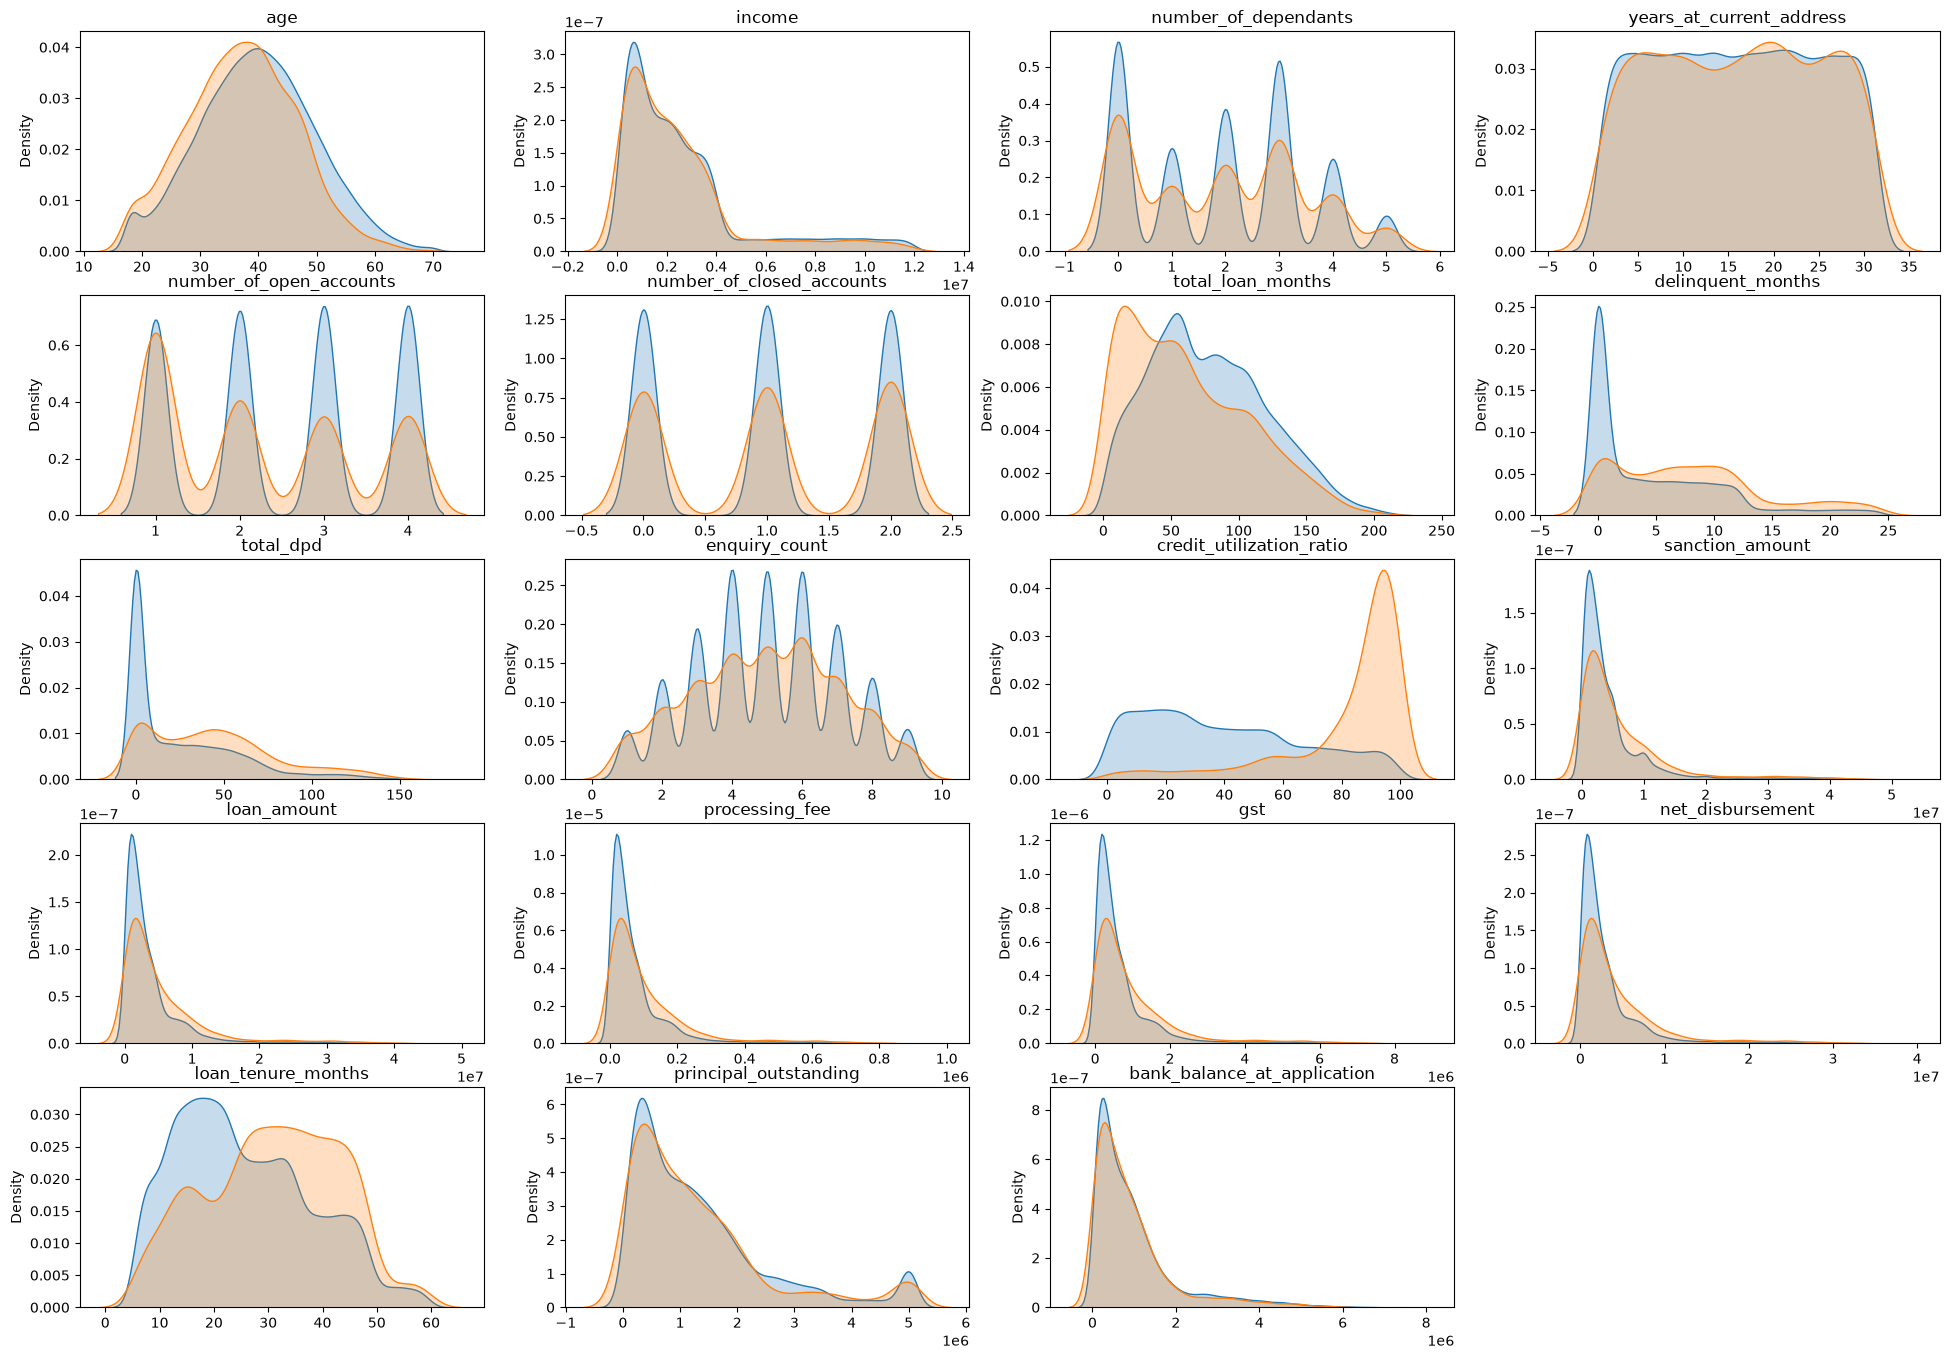

In [40]:
plt.figure(figsize=(24, 20))

for i, col in enumerate(numerical_cols):
    plt.subplot(6, 4, i + 1)
    sns.kdeplot(df_train[col][df_train['default'] == 0], fill=True, label="Default = 0")
    sns.kdeplot(df_train[col][df_train['default'] == 1], fill=True, label="Default = 1")
    plt.title(col)
    plt.xlabel('')

plt.show()

In [41]:
for c in categorical_cols:
    print(df_train[c].value_counts())
    print("\n")

gender
M    22527
F    14968
Name: count, dtype: int64


marital_status
Married    20607
Single     16888
Name: count, dtype: int64


employment_status
Self-Employed    24040
Salaried         13455
Name: count, dtype: int64


residence_type
Owned       21178
Mortgage     8858
Rented       7459
Name: count, dtype: int64


city
Mumbai       3828
Bangalore    3803
Jaipur       3786
Ahmedabad    3773
Delhi        3760
Kolkata      3738
Hyderabad    3726
Pune         3713
Chennai      3698
Lucknow      3670
Name: count, dtype: int64


state
Maharashtra      7541
Karnataka        3803
Rajasthan        3786
Gujarat          3773
Delhi            3760
West Bengal      3738
Telangana        3726
Tamil Nadu       3698
Uttar Pradesh    3670
Name: count, dtype: int64


zipcode
400001    3828
560001    3803
302001    3786
380001    3773
110001    3760
700001    3738
500001    3726
411001    3713
600001    3698
226001    3670
Name: count, dtype: int64


loan_purpose
Personal     13100
Home         1

In [42]:
df_train.replace({
    'loan_purpose': {
        'Personaal': 'Personal'
    }
}, inplace=True)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,...,23442000,468840.0,4219560,18753600,28,5000000,4820526,2020-10-31,2020-11-11,0
32495,C32496,44,F,Single,Salaried,715000,0,Owned,27,Mumbai,...,1149000,22980.0,206820,919200,50,467229,216697,2022-10-22,2022-10-27,0
43675,C43676,38,M,Single,Salaried,3195000,0,Mortgage,26,Chennai,...,11296000,225920.0,2033280,9036800,32,1656773,1383842,2023-12-04,2023-12-29,0
9040,C09041,42,M,Married,Salaried,1500000,2,Mortgage,30,Bangalore,...,1695000,33900.0,305100,1356000,40,1023442,626203,2020-06-18,2020-07-07,0
13077,C13078,58,M,Married,Self-Employed,1817000,4,Owned,29,Pune,...,905000,18100.0,162900,724000,15,651599,585099,2020-11-12,2020-12-07,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28515,C28516,70,M,Single,Self-Employed,2470000,0,Owned,20,Kolkata,...,1420000,28400.0,255600,1136000,12,1022399,501594,2022-05-30,2022-06-09,0
5558,C05559,39,F,Single,Salaried,2472000,0,Rented,26,Kolkata,...,2753000,55060.0,495540,2202400,32,1123466,587429,2020-02-12,2020-02-17,0
45236,C45237,39,M,Married,Self-Employed,1329000,4,Owned,10,Pune,...,4479000,89580.0,806220,3583200,38,913243,517025,2024-01-30,2024-02-04,1
49228,C49229,33,M,Single,Salaried,1274000,2,Owned,26,Chennai,...,1890000,37800.0,340200,1512000,37,635515,475147,2024-06-24,2024-07-21,0


In [43]:
df_train['loan_purpose'].value_counts()

loan_purpose
Personal     13118
Home         11306
Auto          7449
Education     5622
Name: count, dtype: int64

In [44]:
df_test.replace({
    'loan_purpose': {
        'Personaal': 'Personal'
    }
}, inplace=True)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
19205,C19206,36,M,Married,Self-Employed,3728000,3,Owned,24,Jaipur,...,9890000,197800.0,1780200,7912000,46,1745379,806208,2021-06-24,2021-07-23,0
15514,C15515,43,F,Single,Self-Employed,2493000,0,Owned,23,Delhi,...,3087000,61740.0,555660,2469600,18,1675530,1019647,2021-02-09,2021-02-18,0
30367,C30368,30,M,Married,Self-Employed,3114000,4,Owned,27,Delhi,...,3323000,66460.0,598140,2658400,35,1613282,1000932,2022-08-06,2022-08-21,0
35347,C35348,37,F,Single,Salaried,570000,2,Owned,5,Pune,...,1559000,31180.0,280620,1247200,46,398614,167679,2023-02-03,2023-02-04,0
41814,C41815,48,F,Single,Salaried,662000,0,Mortgage,23,Chennai,...,1351000,27020.0,243180,1080800,44,383925,262180,2023-09-27,2023-10-17,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29297,C29298,27,M,Single,Self-Employed,185000,0,Owned,3,Jaipur,...,253000,5060.0,45540,202400,29,96645,65285,2022-06-28,2022-06-30,0
20567,C20568,40,M,Single,Self-Employed,430000,0,Rented,19,Kolkata,...,1363000,27260.0,245340,1090400,35,273282,158171,2021-08-13,2021-08-23,0
681,C00682,28,M,Married,Self-Employed,11961000,5,Rented,15,Bangalore,...,3660000,73200.0,658800,2928000,15,2635199,4652930,2019-08-18,2019-09-16,0
33682,C33683,31,M,Single,Salaried,3430000,1,Owned,29,Delhi,...,12534000,250680.0,2256120,10027200,37,1907851,1029321,2022-12-05,2022-12-17,0


In [45]:
df_test['loan_purpose'].value_counts()

loan_purpose
Personal     4356
Home         3722
Auto         2486
Education    1934
Name: count, dtype: int64

#### Feature Engineering and Feature Selection

In [46]:
df_train.head(1)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,...,23442000,468840.0,4219560,18753600,28,5000000,4820526,2020-10-31,2020-11-11,0


##### Building Some usefull features / ratios based on Domain Understanding of Credit Modelling for our Model Training

1. Loan to Income - (LTI)

In [47]:
df_train['loan_to_income'] = np.where(df_train['income'] != 0, round(df_train.loan_amount / df_train.income, 2), 0)

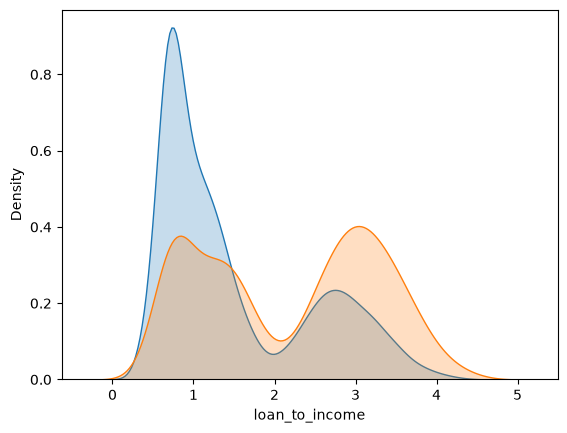

In [48]:
sns.kdeplot(df_train['loan_to_income'][df_train['default'] == 0], fill=True, label="Default = 0")
sns.kdeplot(df_train['loan_to_income'][df_train['default'] == 1], fill=True, label="Default = 1")
plt.show()

In [49]:
df_test['loan_to_income'] = np.where(df_test['income'] != 0, round(df_test.loan_amount / df_test.income, 2), 0)

2. Delinquency Ratio

In [50]:
df_train['delinquency_ratio'] = round(df_train.delinquent_months / df_train.total_loan_months, 2) * 100

<Axes: xlabel='delinquency_ratio', ylabel='Density'>

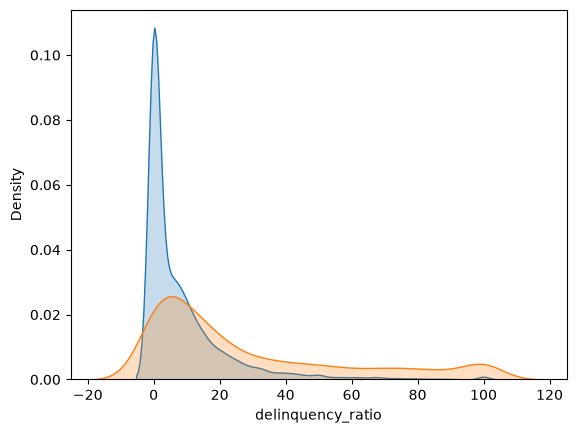

In [51]:
sns.kdeplot(df_train['delinquency_ratio'][df_train['default'] == 0], fill=True, label="Default = 0")
sns.kdeplot(df_train['delinquency_ratio'][df_train['default'] == 1], fill=True, label="Default = 1")

In [52]:
df_test['delinquency_ratio'] = round(df_test.delinquent_months / df_test.total_loan_months, 2) * 100

3. Average DPD Per Delinquency

In [53]:
df_train['avg_dpd_per_delinquency'] = np.where(df_train['delinquent_months'] != 0, round(df_train['total_dpd'] / df_train['delinquent_months'], 2), 0)

<Axes: xlabel='avg_dpd_per_delinquency', ylabel='Density'>

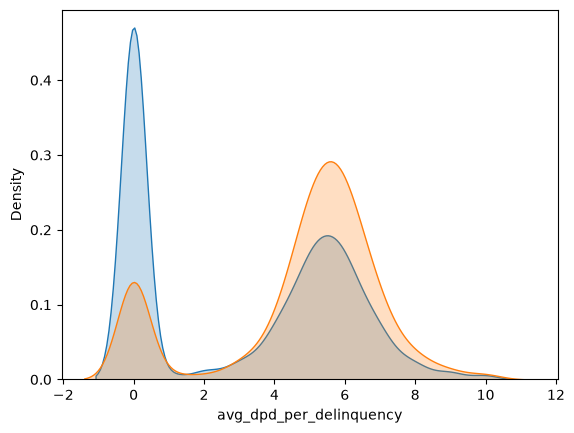

In [54]:
sns.kdeplot(df_train['avg_dpd_per_delinquency'][df_train['default'] == 0], fill=True, label="Defualt = 0")
sns.kdeplot(df_train['avg_dpd_per_delinquency'][df_train['default'] == 1], fill=True, label="Defualt = 1")

In [55]:
df_test['avg_dpd_per_delinquency'] = np.where(df_test['delinquent_months'] != 0, round(df_test['total_dpd'] / df_test['delinquent_months'], 2), 0)

4. Credit Utilization Per Income

In [56]:
df_train['loan_to_income'].describe()

count    37495.000000
mean         1.556421
std          0.973829
min          0.000000
25%          0.770000
50%          1.160000
75%          2.460000
max          4.570000
Name: loan_to_income, dtype: float64

In [57]:
df_train['credit_utilization_per_income'] = np.where(df_train['loan_to_income'] != 0, round(df_train['credit_utilization_ratio'] / df_train['loan_to_income'], 2), 0)

In [58]:
df_train[['credit_utilization_per_income', 'credit_utilization_ratio', 'loan_to_income']]

,credit_utilization_per_income,credit_utilization_ratio,loan_to_income
12746,17.39,36,2.07
32495,3.11,5,1.61
43675,0.00,0,3.54
9040,76.99,87,1.13
13077,142.00,71,0.50
...,...,...,...
28515,22.81,13,0.57
5558,39.64,44,1.11
45236,28.78,97,3.37
49228,16.89,25,1.48


<Axes: xlabel='credit_utilization_per_income', ylabel='Density'>

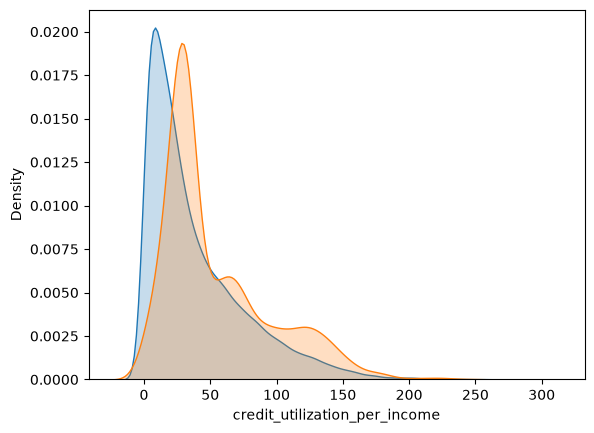

In [59]:
sns.kdeplot(df_train['credit_utilization_per_income'][df_train['default'] == 0], fill=True, label="Default = 0")
sns.kdeplot(df_train['credit_utilization_per_income'][df_train['default'] == 1], fill=True, label="Default = 1")

In [60]:
df_test['credit_utilization_per_income'] = np.where(df_test['loan_to_income'] != 0, round(df_test['credit_utilization_ratio'] / df_test['loan_to_income'], 2), 0)

In [61]:
len(df_train.columns)

37

In [62]:
len(df_test.columns)

37

#### Feature Selection

Removing 'cust_id' and 'loan_id' as it is not that relavant and also the features which are already used in ratios.

In [63]:
df_train_1 = df_train.drop(['cust_id', 'loan_id', 'disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 'total_loan_months', 'delinquent_months', 'total_dpd'], axis = 1).copy()

In [64]:
df_test_1 = df_test.drop(['cust_id', 'loan_id', 'disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 'total_loan_months', 'delinquent_months', 'total_dpd'], axis = 1).copy()

In [65]:
df_train_1.select_dtypes(include=['int64', 'float64']).columns

Index(['age', 'number_of_dependants', 'years_at_current_address',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'sanction_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'default', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency',
       'credit_utilization_per_income'],
      dtype='str')

In [66]:
cols_to_scale = ['age', 'number_of_dependants', 'years_at_current_address',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'sanction_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency',
       'credit_utilization_per_income']

In [67]:
X_train = df_train_1.drop('default', axis=1)
y_train = df_train_1['default']

X_test = df_test_1.drop('default', axis=1)
y_test = df_test_1['default']

In [68]:
X_train.describe()

,age,number_of_dependants,years_at_current_address,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income
count,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000,3.749500e+04,37495.000000,3.749500e+04,3.749500e+04,37495.000000,3.749500e+04,3.749500e+04,37495.000000,37495.000000,37495.000000,37495.000000
mean,39.540152,1.944526,15.997840,2.502867,1.001120,5.008721,43.424963,4.699962e+06,79926.048807,7.193344e+05,3.197042e+06,25.961968,1.333807e+06,9.862870e+05,1.556421,10.332711,3.283995,40.232467
std,9.858341,1.535923,8.921127,1.119106,0.814009,2.029258,29.392614,6.258187e+06,107443.444689,9.669910e+05,4.297738e+06,12.447645,1.213727e+06,1.043161e+06,0.973829,17.300860,2.906722,38.513456
min,18.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,6.000000,-1.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,33.000000,0.000000,8.000000,1.000000,0.000000,4.000000,18.000000,1.142000e+06,19220.000000,1.729800e+05,7.688000e+05,16.000000,4.221215e+05,2.870010e+05,0.770000,0.000000,0.000000,11.760000
50%,39.000000,2.000000,16.000000,3.000000,1.000000,5.000000,39.000000,2.644000e+06,44600.000000,4.014000e+05,1.784000e+06,24.000000,9.974140e+05,6.650360e+05,1.160000,4.000000,4.330000,27.590000
75%,46.000000,3.000000,24.000000,4.000000,2.000000,6.000000,67.000000,5.178500e+06,92380.000000,8.314200e+05,3.695200e+06,35.000000,1.784866e+06,1.234080e+06,2.460000,13.000000,5.740000,58.180000
max,70.000000,5.000000,31.000000,4.000000,2.000000,9.000000,99.000000,5.217500e+07,956380.000000,8.607420e+06,3.825520e+07,59.000000,5.000000e+06,7.846643e+06,4.570000,100.000000,10.000000,291.180000


In [69]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

In [70]:
X_train.describe()

,age,number_of_dependants,years_at_current_address,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income
count,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000,37495.000000
mean,0.414234,0.388905,0.499928,0.500956,0.500560,0.501090,0.438636,0.090081,0.083571,0.083571,0.083571,0.376641,0.266762,0.125695,0.340573,0.103327,0.328399,0.138170
std,0.189583,0.307185,0.297371,0.373035,0.407005,0.253657,0.296895,0.119946,0.112344,0.112344,0.112344,0.234861,0.242745,0.132944,0.213092,0.173009,0.290672,0.132267
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.288462,0.000000,0.233333,0.000000,0.000000,0.375000,0.181818,0.021888,0.020097,0.020097,0.020097,0.188679,0.084424,0.036576,0.168490,0.000000,0.000000,0.040387
50%,0.403846,0.400000,0.500000,0.666667,0.500000,0.500000,0.393939,0.050676,0.046634,0.046634,0.046634,0.339623,0.199483,0.084754,0.253829,0.040000,0.433000,0.094752
75%,0.538462,0.600000,0.766667,1.000000,1.000000,0.625000,0.676768,0.099253,0.096593,0.096593,0.096593,0.547170,0.356973,0.157275,0.538293,0.130000,0.574000,0.199808
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [71]:
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_test.describe()

,age,number_of_dependants,years_at_current_address,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income
count,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000
mean,0.415005,0.384910,0.502688,0.497306,0.500400,0.501490,0.436033,0.090468,0.083868,0.083868,0.083868,0.375102,0.269786,0.127099,0.339420,0.106061,0.333835,0.136870
std,0.188766,0.306865,0.298092,0.372564,0.407234,0.253618,0.295406,0.120676,0.112742,0.112742,0.112742,0.233785,0.243565,0.134374,0.211342,0.173120,0.289692,0.130691
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.288462,0.000000,0.233333,0.000000,0.000000,0.375000,0.181818,0.022295,0.020520,0.020520,0.020520,0.188679,0.086183,0.036544,0.170678,0.000000,0.000000,0.040593
50%,0.423077,0.400000,0.500000,0.333333,0.500000,0.500000,0.393939,0.051500,0.047366,0.047366,0.047366,0.339623,0.203821,0.086286,0.253829,0.040000,0.440000,0.093310
75%,0.538462,0.600000,0.766667,0.666667,1.000000,0.625000,0.676768,0.098644,0.095976,0.095976,0.095976,0.547170,0.361423,0.159853,0.531729,0.130000,0.575000,0.198812
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.981275,0.963759,0.963759,0.963759,1.000000,1.000000,0.939304,1.004376,1.000000,1.000000,0.961605


##### Using VIF to calculate variance of all numeric features on target variable for feature selection

In [72]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

calculate_vif(X_train[cols_to_scale])


C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Column,VIF
0,age,5.861863
1,number_of_dependants,2.730626
2,years_at_current_address,3.428816
3,number_of_open_accounts,4.389375
4,number_of_closed_accounts,2.390667
5,enquiry_count,6.428248
6,credit_utilization_ratio,10.375166
7,sanction_amount,102.228442
8,processing_fee,inf
9,gst,inf


In [73]:
features_to_drop_vif = ['processing_fee', 'gst', 'net_disbursement', 'principal_outstanding', 'sanction_amount']
X_train_1 = X_train.drop(features_to_drop_vif, axis=1).copy()

In [74]:
X_test_1 = X_test.drop(features_to_drop_vif, axis=1).copy()

In [75]:
X_train_1.select_dtypes(include=['int64', 'float64']).columns

Index(['age', 'number_of_dependants', 'years_at_current_address',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_tenure_months',
       'bank_balance_at_application', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'credit_utilization_per_income'],
      dtype='str')

In [76]:
vif_df = calculate_vif(X_train_1[['age', 'number_of_dependants', 'years_at_current_address',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_tenure_months',
       'bank_balance_at_application', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'credit_utilization_per_income']])
vif_df

,Column,VIF
0,age,5.475134
1,number_of_dependants,2.725203
2,years_at_current_address,3.401777
3,number_of_open_accounts,4.350763
4,number_of_closed_accounts,2.371542
5,enquiry_count,6.389592
6,credit_utilization_ratio,10.056773
7,loan_tenure_months,6.277112
8,bank_balance_at_application,1.926459
9,loan_to_income,7.625006


- We are not removing credit utilization ratio as it has business relavance.

In [77]:
selected_features = vif_df.Column.values
selected_features

<ArrowStringArray>
[                          'age',          'number_of_dependants',
      'years_at_current_address',       'number_of_open_accounts',
     'number_of_closed_accounts',                 'enquiry_count',
      'credit_utilization_ratio',            'loan_tenure_months',
   'bank_balance_at_application',                'loan_to_income',
             'delinquency_ratio',       'avg_dpd_per_delinquency',
 'credit_utilization_per_income']
Length: 13, dtype: str

#### Feature Selection using WOE(Weight of Evidence) and IV(Information Value) for both categorical and continous variables.

In [78]:
def calculate_woe_vif(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['count', 'sum'])
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'good'})
    grouped['bad'] = grouped['total'] - grouped['good']
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()
    grouped['good_pct'] = round(grouped['good'] / total_good, 2) 
    grouped['bad_pct'] = round(grouped['bad'] / total_bad, 2)
    grouped['WOE'] = np.log(grouped['good_pct'] / grouped['bad_pct'])
    grouped['IV'] = grouped['WOE'] * (grouped['good_pct'] - grouped['bad_pct'])

    grouped['WOE'] = grouped['WOE'].replace([np.inf, -np.inf], 0)
    grouped['IV'] = grouped['IV'].replace([np.inf, -np.inf], 0)

    total_iv = grouped['IV'].sum()

    return grouped, total_iv

In [79]:
iv_values = {}

for feature in X_train_1.columns:
    if X_train_1[feature].dtype == 'str':
        _, iv = calculate_woe_vif(pd.concat([X_train_1, y_train],axis=1), feature, 'default' )
    else:
        X_binned = pd.cut(X_train_1[feature], bins=10, labels=False)
        _, iv = calculate_woe_vif(pd.concat([X_binned, y_train],axis=1), feature, 'default' )
    iv_values[feature] = iv
        
iv_values

C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


{'age': np.float64(0.08910066498056395),
 'gender': np.float64(0.000414997309067526),
 'marital_status': np.float64(0.0016105276724017546),
 'employment_status': np.float64(0.0038415578057969186),
 'number_of_dependants': np.float64(0.003096811458423914),
 'residence_type': np.float64(0.24752122058827508),
 'years_at_current_address': np.float64(0.001053605156578265),
 'city': np.float64(0.003060312111199777),
 'state': np.float64(0.003060312111199777),
 'zipcode': np.float64(0.003060312111199777),
 'number_of_open_accounts': np.float64(0.0894236746133962),
 'number_of_closed_accounts': np.float64(0.0017830562186230143),
 'enquiry_count': np.float64(0.007890786162085255),
 'credit_utilization_ratio': np.float64(2.2813839318145988),
 'loan_purpose': np.float64(0.3748452582664711),
 'loan_type': np.float64(0.16520280511656427),
 'loan_tenure_months': np.float64(0.22863427515064944),
 'bank_balance_at_application': np.float64(0.003956050400571677),
 'loan_to_income': np.float64(0.45431983

In [80]:
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

woe_iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
woe_iv_df = woe_iv_df.sort_values(by='IV', ascending=False)
woe_iv_df

,Feature,IV
13,credit_utilization_ratio,2.281
18,loan_to_income,0.454
20,avg_dpd_per_delinquency,0.390
14,loan_purpose,0.375
19,delinquency_ratio,0.312
5,residence_type,0.248
16,loan_tenure_months,0.229
21,credit_utilization_per_income,0.202
15,loan_type,0.165
10,number_of_open_accounts,0.089


In [81]:
selected_features_woe_iv = [feature for feature, iv in iv_values.items() if iv > 0.02]
selected_features_woe_iv

['age',
 'residence_type',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'loan_purpose',
 'loan_type',
 'loan_tenure_months',
 'loan_to_income',
 'delinquency_ratio',
 'avg_dpd_per_delinquency',
 'credit_utilization_per_income']

In [82]:
X_train_reduced = X_train_1[selected_features_woe_iv].copy()
X_test_reduced = X_test_1[selected_features_woe_iv].copy()

#### Feature Encoding

In [83]:
X_train_encoded = pd.get_dummies(X_train_reduced, drop_first=True, dtype='float64')
X_test_encoded = pd.get_dummies(X_test_reduced, drop_first=True, dtype='float64')

In [84]:
X_train_encoded.head()

,age,number_of_open_accounts,credit_utilization_ratio,loan_tenure_months,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
12746,0.788,1.000,0.364,0.415,0.453,0.130,0.590,0.060,1.000,0.000,0.000,1.000,0.000,0.000
32495,0.500,0.667,0.051,0.830,0.352,0.060,0.620,0.011,1.000,0.000,1.000,0.000,0.000,0.000
43675,0.385,0.000,0.000,0.491,0.775,0.220,0.558,0.000,0.000,0.000,0.000,1.000,0.000,0.000
9040,0.462,0.667,0.879,0.642,0.247,0.000,0.000,0.264,0.000,0.000,1.000,0.000,0.000,0.000
13077,0.769,0.000,0.717,0.170,0.109,0.000,0.000,0.488,1.000,0.000,0.000,0.000,1.000,1.000


In [85]:
X_test_encoded.head()

,age,number_of_open_accounts,credit_utilization_ratio,loan_tenure_months,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
19205,0.346,0.333,0.990,0.755,0.580,0.000,0.000,0.127,1.000,0.000,0.000,1.000,0.000,0.000
15514,0.481,1.000,0.323,0.226,0.271,0.000,0.000,0.089,1.000,0.000,1.000,0.000,0.000,0.000
30367,0.231,0.667,0.828,0.547,0.234,0.000,0.000,0.263,1.000,0.000,0.000,0.000,0.000,0.000
35347,0.365,1.000,0.485,0.755,0.600,0.020,0.700,0.060,1.000,0.000,0.000,1.000,0.000,0.000
41814,0.577,0.667,0.980,0.717,0.446,0.110,0.636,0.163,0.000,0.000,0.000,1.000,0.000,0.000


#### Model Training

- Attemp 1
    1. Logistic Regression
    2. XGBoost
    3. Random Forest Classifier 

In [86]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix

In [87]:
model = LogisticRegression()
model.fit(X_train_encoded, y_train)

y_pred_lr = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred_lr)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11424
           1       0.85      0.72      0.78      1074

    accuracy                           0.96     12498
   macro avg       0.91      0.85      0.88     12498
weighted avg       0.96      0.96      0.96     12498



Confusion Matrix for Logistic Regression Model


<Axes: >

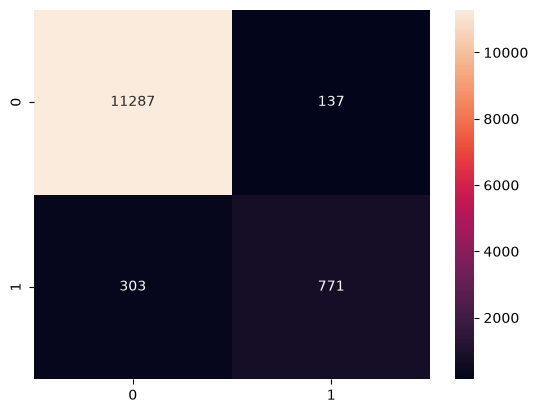

In [88]:
print("Confusion Matrix for Logistic Regression Model")
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d')

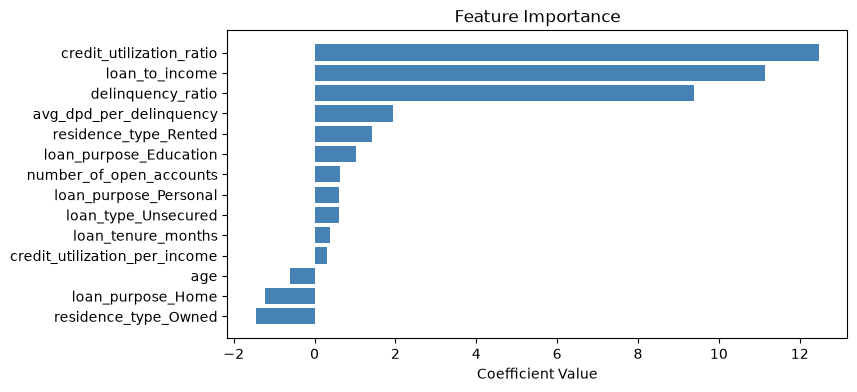

In [89]:
def plot_feature_importances(coef, columns):
    feature_importance = coef
    feature_importance
    coef_df = pd.DataFrame(feature_importance, index=columns, columns=['Coefficients'])
    coef_df

    coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

    # Ploting
    plt.figure(figsize=(8, 4))
    plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
    plt.xlabel('Coefficient Value')
    plt.title('Feature Importance')
    plt.show()

plot_feature_importances(model.coef_[0], X_train_encoded.columns)

In [90]:
rfc_model = RandomForestClassifier()
rfc_model.fit(X_train_encoded, y_train)

y_pred_rfc = rfc_model.predict(X_test_encoded)

print(f"Random Forest Classifier Report\n")
print(classification_report(y_test, y_pred_rfc))

Random Forest Classifier Report

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11424
           1       0.84      0.73      0.78      1074

    accuracy                           0.97     12498
   macro avg       0.91      0.86      0.88     12498
weighted avg       0.96      0.97      0.96     12498



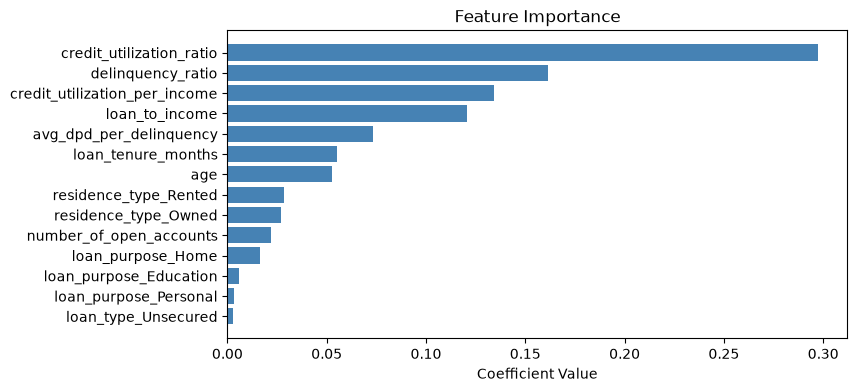

In [91]:
plot_feature_importances(rfc_model.feature_importances_, X_train_encoded.columns)

Confusion Matrix for Logistic Regression Model


<Axes: >

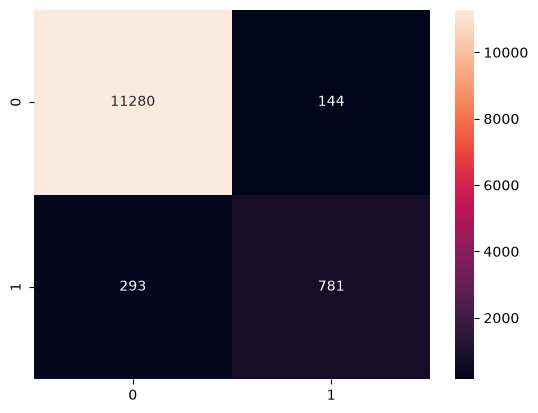

In [92]:
print("Confusion Matrix for Logistic Regression Model")
cm = confusion_matrix(y_test, y_pred_rfc)
sns.heatmap(cm, annot=True, fmt='d')

In [93]:
xgb_model = XGBClassifier()
xgb_model.fit(X_train_encoded, y_train)

y_pred_xgb = xgb_model.predict(X_test_encoded)

print(f"XGBoost Report\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11424
           1       0.83      0.75      0.79      1074

    accuracy                           0.97     12498
   macro avg       0.90      0.87      0.88     12498
weighted avg       0.96      0.97      0.96     12498



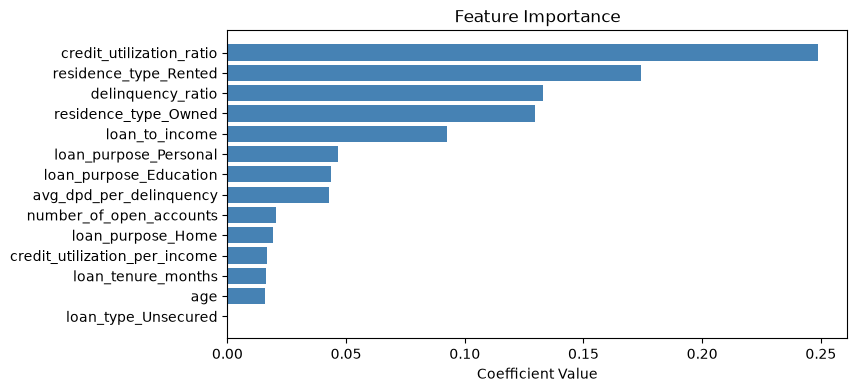

In [94]:
plot_feature_importances(xgb_model.feature_importances_, X_train_encoded.columns)

Feature Importance of XGBoost Model


<Axes: >

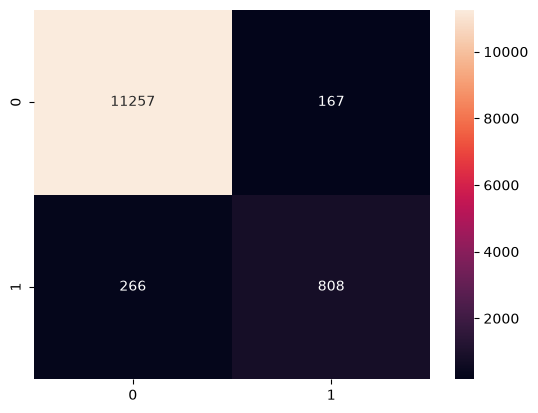

In [95]:
print(f"Feature Importance of XGBoost Model")
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d')

- Conclusion on Attemp 1

Recall for Logistic Regression and Random Forest Classifier is equal and even there is not much difference in recall with XGB and Log Reg model.

==============================================================================================================

Attempt 2

- Use RandomizedSearchCV for finding Best Parameters on Logistic Regression and XGBoost Model


In [96]:
from sklearn.model_selection import RandomizedSearchCV

In [97]:
param_dist_log = {
    "C": np.logspace(-4, 4, 20),
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],
    "max_iter": [1000, 2000, 3000]
}

In [98]:
randomized_search_log = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist_log,
    n_iter=50,
    scoring='recall',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

randomized_search_log.fit(X_train_encoded, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'max_iter': [1000, 2000, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selecte

In [99]:
print("Best Parameters:")
print(randomized_search_log.best_params_)

print("\nBest CV Recall:")
print(randomized_search_log.best_score_)

Best Parameters:
{'solver': 'saga', 'penalty': 'l1', 'max_iter': 2000, 'C': np.float64(10000.0)}

Best CV Recall:
0.7139347103856709


In [100]:
best_log_model = randomized_search_log.best_estimator_

y_pred_best_log_model = best_log_model.predict(X_test_encoded)

print(classification_report(y_test, y_pred_best_log_model))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11424
           1       0.83      0.74      0.78      1074

    accuracy                           0.96     12498
   macro avg       0.90      0.86      0.88     12498
weighted avg       0.96      0.96      0.96     12498



Confusion Matrix for Best Logistic Regression Model


<Axes: >

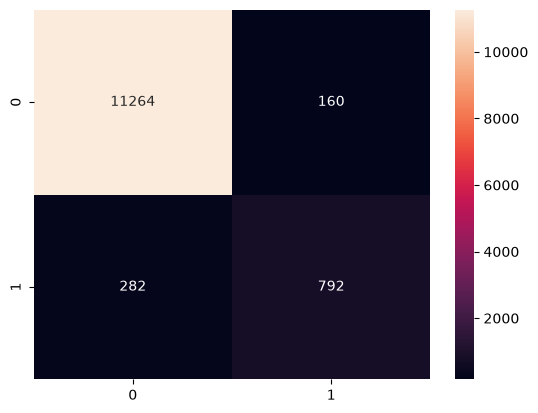

In [101]:
print("Confusion Matrix for Best Logistic Regression Model")
cm = confusion_matrix(y_test, y_pred_best_log_model)
sns.heatmap(cm, annot=True, fmt='d')

In [102]:
from scipy.stats import randint, uniform

param_dist_xgb = {
    'n_estimators': randint(20, 100),           
    'max_depth': randint(3, 8),                 
    'learning_rate': uniform(0.05, 0.25),        
    'subsample': uniform(0.7, 0.3),              
    'colsample_bytree': uniform(0.7, 0.3),       
    'min_child_weight': randint(1, 6),
    'gamma': uniform(0, 0.3),
}

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',    
    random_state=42,
    n_jobs=-1 
)

randomized_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring='recall',
    cv=3,
    random_state=42,
    n_jobs=-1
)

randomized_search_xgb.fit(X_train_encoded, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....002CB2AEA6490>, 'gamma': <scipy.stats....002CB2ABE90F0>, 'learning_rate': <scipy.stats....002CB2AB68C20>, 'max_depth': <scipy.stats....002CB2AEA5E50>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``pre

In [103]:
print(f"Best Params XGB Model")
print(randomized_search_xgb.best_params_)
print(f"Best Score - Recall")
print(randomized_search_xgb.best_score_)

Best Params XGB Model
{'colsample_bytree': np.float64(0.8953231076505833), 'gamma': np.float64(0.2744879026631342), 'learning_rate': np.float64(0.26250964444744984), 'max_depth': 6, 'min_child_weight': 2, 'n_estimators': 52, 'subsample': np.float64(0.7190675050858071)}
Best Score - Recall
0.7561260519971706


In [104]:
best_xgb_model = randomized_search_xgb.best_estimator_
best_xgb_model.fit(X_train_encoded, y_train)
y_pred_best_xgb_model = best_xgb_model.predict(X_test_encoded)

print("Classification Report - Best XGB Model")
print(classification_report(y_test, y_pred_best_xgb_model))

Classification Report - Best XGB Model
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11424
           1       0.82      0.76      0.79      1074

    accuracy                           0.96     12498
   macro avg       0.90      0.87      0.88     12498
weighted avg       0.96      0.96      0.96     12498



Confusion Matrix for Best XGBoost Model


<Axes: >

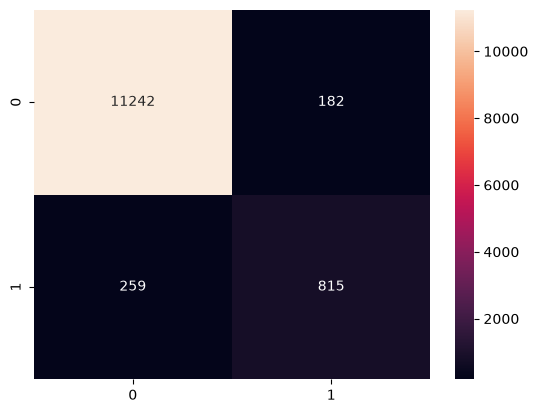

In [105]:
print("Confusion Matrix for Best XGBoost Model")
cm = confusion_matrix(y_test, y_pred_best_xgb_model)
sns.heatmap(cm, annot=True, fmt='d')

- Conclusion for Attemp 2 : Hyperparameter Tuning using RandomizedSearchCV

1. We ran RandomizedSearchCV on both Log Regression and XGBoost Classification model out which the best estimator XGB gave a Recall - 76% and Precision - 82% and on the other hand Logistic Regression gave a Recall - 74% and Precision of 83%.
2. Since, there is not much difference in performance we will finalize Logistic Regression Model for this project as it has higher explainibililty.

======================================================================================================================

- Attemp 3

Using Sampling Techinques like RandomUnderSampler and SMOTETomek on Logistic Regression Model.

In [106]:
y_train.value_counts()

default
0    34272
1     3223
Name: count, dtype: int64

In [107]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_rus, y_train_rus = rus.fit_resample(X_train_encoded, y_train)

y_train_rus.value_counts()

default
0    3223
1    3223
Name: count, dtype: int64

In [108]:
best_log_model.fit(X_train_rus, y_train_rus)

y_pred_rus = best_log_model.predict(X_test_encoded)

print(f"Classification Report for Sampled Data using Random Under Sampler")
print(classification_report(y_test, y_pred_rus))

Classification Report for Sampled Data using Random Under Sampler
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11424
           1       0.54      0.95      0.69      1074

    accuracy                           0.93     12498
   macro avg       0.77      0.94      0.83     12498
weighted avg       0.96      0.93      0.94     12498



C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Confusion Matrix of Log Model with Sampled Data


<Axes: >

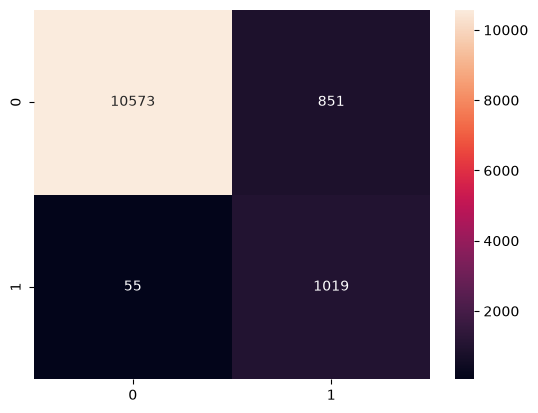

In [109]:
print(f"Confusion Matrix of Log Model with Sampled Data")
cm = confusion_matrix(y_test, y_pred_rus)
sns.heatmap(cm, annot=True, fmt='d')

In [110]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)

X_train_smt, y_train_smt = smt.fit_resample(X_train_encoded, y_train)

y_train_smt.value_counts()

default
0    34222
1    34222
Name: count, dtype: int64

In [111]:
best_log_model.fit(X_train_smt, y_train_smt)

y_pred_smt = best_log_model.predict(X_test_encoded)

print("Classification Report of Log Model on Sampled Data using SMOTETomek")
print(classification_report(y_test, y_pred_smt))

C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Classification Report of Log Model on Sampled Data using SMOTETomek
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11424
           1       0.56      0.95      0.70      1074

    accuracy                           0.93     12498
   macro avg       0.78      0.94      0.83     12498
weighted avg       0.96      0.93      0.94     12498



#### HyperParameter Tuning using Optuna

In [112]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'C' : trial.suggest_float("C", 1e-4, 1e4, log=True),
        'penalty': trial.suggest_categorical("penalty", ["l1", "l2"]),
        'solver' : trial.suggest_categorical("solver", ["liblinear", "saga"]),
        'max_iter' : trial.suggest_categorical("max_iter", [1000, 2000, 3000, 4000]),
        'class_weight' : trial.suggest_categorical("class_weight", [None, 'balanced'])
    }

    model = LogisticRegression(**params)

    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=5, scoring='f1', n_jobs=-1)

    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-27 12:16:34,500] A new study created in memory with name: no-name-f88dd978-04ab-4a65-920c-f994ca0363ec
[I 2026-08-27 12:16:35,028] Trial 0 finished with value: 0.8839376456848169 and parameters: {'C': 0.0007261889827642854, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 1000, 'class_weight': None}. Best is trial 0 with value: 0.8839376456848169.
[I 2026-08-27 12:16:35,346] Trial 1 finished with value: 0.0 and parameters: {'C': 0.0001616224726846062, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 2000, 'class_weight': None}. Best is trial 0 with value: 0.8839376456848169.
[I 2026-08-27 12:16:36,169] Trial 2 finished with value: 0.9466028715464958 and parameters: {'C': 1174.8378154920983, 'penalty': 'l2', 

In [113]:
print("Best F1-Score: ")
print(study.best_value)
print("Best Params: ")
print(study.best_params)

Best F1-Score: 
0.9467098385289263
Best Params: 
{'C': 5.820860731438837, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 4000, 'class_weight': 'balanced'}


In [114]:
best_log_model = LogisticRegression(**study.best_params)

best_log_model.fit(X_train_smt, y_train_smt)

y_pred = best_log_model.predict(X_test_encoded)

print(classification_report(y_test, y_pred))

C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11424
           1       0.56      0.95      0.70      1074

    accuracy                           0.93     12498
   macro avg       0.78      0.94      0.83     12498
weighted avg       0.96      0.93      0.94     12498



#### Model Evaluation: ROC-AUC Curve

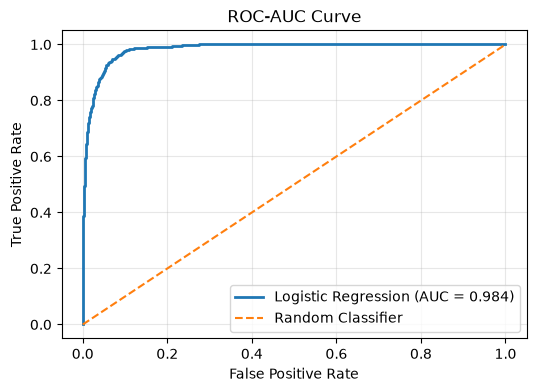

In [115]:
probabilities = best_log_model.predict_proba(X_test_encoded)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, probabilities)

area = auc(fpr, tpr)

# Plot ROC-AUC curve
plt.figure(figsize=(6, 4))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {area:.3f})",
    linewidth=2
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

#### Model Evaluation: Rank Ordering, KS Statistic and Gini Coefficient

In [116]:
def generate_rank_ordering_ks_stats(actual, probabilities, bin_size):
    df = pd.DataFrame({
        'default_truth': actual,
        'default_probability': probabilities
    })

    df['decile'] = pd.qcut(df['default_probability'], bin_size, labels=False, duplicates='drop')

    grouped = df.groupby('decile').apply(lambda x: pd.Series({
        'min_probability': x['default_probability'].min(),
        'max_probability': x['default_probability'].max(),
        'events': x['default_truth'].sum(),
        'non_events': x['default_truth'].count() - x['default_truth'].sum()
    }))

    grouped.sort_values(by='decile', ascending=False, inplace=True)
    grouped.reset_index(inplace=True)

    grouped['event_rate'] = grouped['events'] * 100 / (grouped['events'] + grouped['non_events'])
    grouped['non_event_rate'] = grouped['events'] * 100 / (grouped['events'] + grouped['non_events'])
    grouped['cum_events'] = grouped['events'].cumsum()
    grouped['cum_non_events'] = grouped['non_events'].cumsum()
    grouped['cum_event_rate'] = grouped['cum_events'] * 100 / grouped['events'].sum()
    grouped['cum_non_event_rate'] = grouped['cum_non_events'] * 100 / grouped['non_events'].sum()
    grouped['KS'] = abs(grouped['cum_event_rate'] - grouped['cum_non_event_rate'])

    return grouped

In [117]:
generate_rank_ordering_ks_stats(y_test, best_log_model.predict_proba(X_test_encoded)[:, 1], 10)

,decile,min_probability,max_probability,events,non_events,event_rate,non_event_rate,cum_events,cum_non_events,cum_event_rate,cum_non_event_rate,KS
0,9,0.819,1.000,902.000,348.000,72.160,72.160,902.000,348.000,83.985,3.046,80.939
1,8,0.213,0.818,157.000,1093.000,12.560,12.560,1059.000,1441.000,98.603,12.614,85.990
2,7,0.028,0.211,12.000,1238.000,0.960,0.960,1071.000,2679.000,99.721,23.451,76.270
3,6,0.004,0.028,3.000,1246.000,0.240,0.240,1074.000,3925.000,100.000,34.357,65.643
4,5,0.001,0.004,0.000,1250.000,0.000,0.000,1074.000,5175.000,100.000,45.299,54.701
5,4,0.000,0.001,0.000,1250.000,0.000,0.000,1074.000,6425.000,100.000,56.241,43.759
6,3,0.000,0.000,0.000,1249.000,0.000,0.000,1074.000,7674.000,100.000,67.174,32.826
7,2,0.000,0.000,0.000,1250.000,0.000,0.000,1074.000,8924.000,100.000,78.116,21.884
8,1,0.000,0.000,0.000,1250.000,0.000,0.000,1074.000,10174.000,100.000,89.058,10.942
9,0,0.000,0.000,0.000,1250.000,0.000,0.000,1074.000,11424.000,100.000,100.000,0.000


**Insights from the Decile Table**

1. Top Deciles

* The first decile (Decile 9) has a high event rate of 72.00% and a non-event rate of 28.00%. This indicates that the model is highly confident in predicting events in this decile.
* The second decile (Decile 8) also shows a significant event rate of 12.72%, with a cumulative event rate reaching 98.6%.

2. Middle Deciles:

* Deciles 7 and 6 show a significant drop in event rates

3. Lower Deciles:

* Deciles 5 to 0 show zero events, with all predictions being non-events. These deciles collectively have a non-event rate of 100%.

4. KS Statistic:

* The KS statistic, which is the maximum difference between cumulative event rates and cumulative non-event rates, is highest at Decile 8 with a value of 85.98%. This suggests that the model performs best at distinguishing between events and non-events up to this decile.

* The KS value gradually decreases in the following deciles, indicating a decrease in model performance for distinguishing between events and non-events.

gini coefficient

In [118]:
gini_coefficient = 2 * area - 1

print("AUC: ", area)
print("Gini-Coefficient", gini_coefficient)

AUC:  0.9837793706868223
Gini-Coefficient 0.9675587413736446


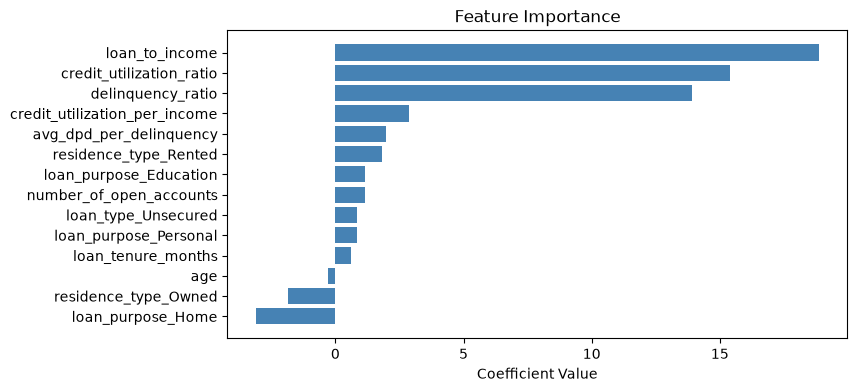

In [119]:
final_model =  best_log_model
plot_feature_importances(final_model.coef_[0], X_train_smt.columns)